1. Please generate the low panel of Figure 2.7 with k = 3, compare them with k = 1 and comment.

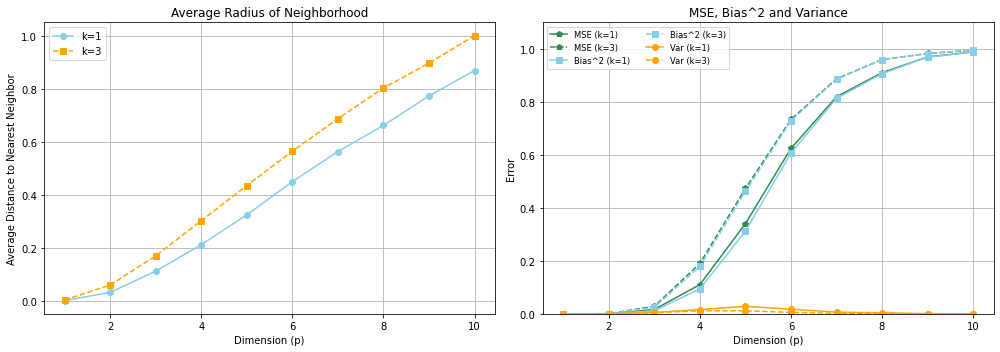

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f1(k_neighbors, n_samples=1000, n_simulations=500, p_max=10):
    mse_list = []
    bias_sq_list = []
    var_list = []
    avg_radius_list = []
    x0 = 0.0 
    
    for p in range(1, p_max + 1):
        y_hat_list = []
        radii = []
        
        for _ in range(n_simulations):

            X = np.random.uniform(-1, 1, (n_samples, p))
            dist_sq = np.sum(X**2, axis=1) # generate f(x)=exp(-8*||X||^2)
            y = np.exp(-8 * dist_sq)
            dist_to_x0 = np.sqrt(dist_sq) # find nearest-point to x0
            idx = np.argsort(dist_to_x0)[:k_neighbors]
            y_hat = np.mean(y[idx])  # y_hat 並記錄[最遠]point半徑
            y_hat_list.append(y_hat)
            avg_radius_list.append(dist_to_x0[idx[-1]]) 
        y_hat_list = np.array(y_hat_list)
        f_x0 = 1.0  # true val. f(0)=1
        
        expected_y_hat = np.mean(y_hat_list)
        bias_sq = (f_x0 - expected_y_hat)**2
        variance = np.var(y_hat_list)
        mse = np.mean((y_hat_list - f_x0)**2)
        
        mse_list.append(mse)
        bias_sq_list.append(bias_sq)
        var_list.append(variance)
        
    return mse_list, bias_sq_list, var_list, np.mean(np.array(avg_radius_list).reshape(p_max, -1), axis=1)

p_range = np.arange(1, 11) # execuate
res1 = f1(k_neighbors=1)
res3 = f1(k_neighbors=3)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(p_range, res1[3], 'o-', label='k=1', color='skyblue')
ax[0].plot(p_range, res3[3], 's--', label='k=3', color='orange')
ax[0].set_xlabel('Dimension (p)')
ax[0].set_ylabel('Average Distance to Nearest Neighbor')
ax[0].set_title('Average Radius of Neighborhood')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(p_range, res1[0], 'p-', label='MSE (k=1)', color='seagreen')
ax[1].plot(p_range, res3[0], 'p--', label='MSE (k=3)', color='seagreen')
ax[1].plot(p_range, res1[1], 's-', label='Bias^2 (k=1)', color='skyblue')
ax[1].plot(p_range, res3[1], 's--', label='Bias^2 (k=3)', color='skyblue')
ax[1].plot(p_range, res1[2], 'o-', label='Var (k=1)', color='orange')
ax[1].plot(p_range, res3[2], 'o--', label='Var (k=3)', color='orange')

ax[1].set_xlabel('Dimension (p)')
ax[1].set_ylabel('Error')
ax[1].set_title('MSE, Bias^2 and Variance')
ax[1].set_ylim(0, 1.1)
ax[1].legend(fontsize='small', ncol=2)
ax[1].grid(True)

plt.tight_layout()
plt.show()

Q2

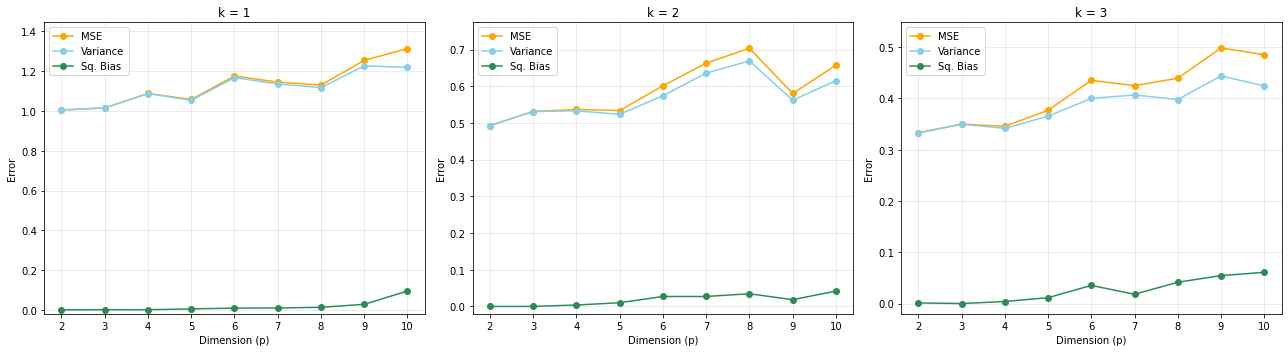

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = 500    
runs = 1000  
p_range = np.arange(2, 11)
k = [1, 2, 3]

def f2(X): # f(X)=X1^2+0.5*(X2+1)^3
    return X[:, 0]**2 + 0.5 * (X[:, 1] + 1)**3

def run_simulation(k):
    mse_list, bias_sq_list, var_list = [], [], []
    
    for p in p_range:
        y_hat_results = []
        for _ in range(runs):

            X_train = np.random.uniform(-1, 1, (n, p))
            y_train = f2(X_train) + np.random.normal(0, 1, n) # 加上 epsilon ~ N(0,1)
            dist_to_origin = np.linalg.norm(X_train, axis=1)
            nearest_idx = np.argsort(dist_to_origin)[:k]
            
            y_hat = np.mean(y_train[nearest_idx])
            y_hat_results.append(y_hat)
            
        y_hat_results = np.array(y_hat_results)
        f_x0 = 0.5 
        
        expected_y_hat = np.mean(y_hat_results)
        bias_sq = (f_x0 - expected_y_hat)**2
        variance = np.var(y_hat_results)
        mse = np.mean((y_hat_results - f_x0)**2)
        
        mse_list.append(mse)
        bias_sq_list.append(bias_sq)
        var_list.append(variance)
        
    return mse_list, bias_sq_list, var_list

plt.figure(figsize=(18, 5))
colors = {'MSE': 'orange', 'Var': 'skyblue', 'Bias': 'seagreen'}

for i, k in enumerate(k):
    mse, b_sq, var = run_simulation(k)
    
    plt.subplot(1, 3, i+1)
    plt.plot(p_range, mse, 'o-', color=colors['MSE'], label='MSE')
    plt.plot(p_range, var, 'o-', color=colors['Var'], label='Variance')
    plt.plot(p_range, b_sq, 'o-', color=colors['Bias'], label='Sq. Bias')
    
    plt.title(f'k = {k}')
    plt.xlabel('Dimension (p)')
    plt.ylabel('Error')
    plt.ylim(-0.02, max(max(mse)*1.1, 0.5)) # 根據數據調整高度
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optional

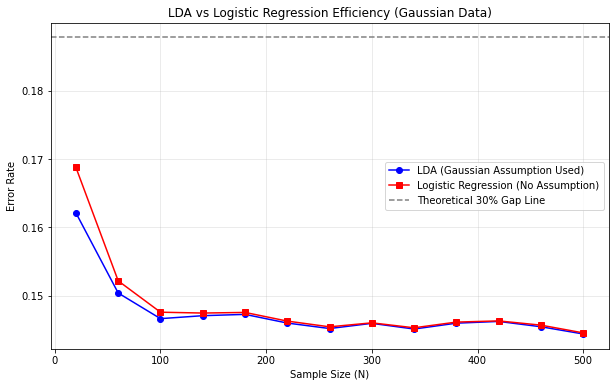

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


np.random.seed(42)
runs = 500  
n = np.arange(20, 501, 40) 
p = 2 
mu1 = np.array([0, 0])
mu2 = np.array([1.5, 1.5])
sigma = np.eye(p)

def f3():
    lda_errors = []
    logreg_errors = []

    for N in n:
        lda_sim_err = []
        logreg_sim_err = []
        
        for _ in range(runs):
          
            X1 = np.random.multivariate_normal(mu1, sigma, N // 2)
            X2 = np.random.multivariate_normal(mu2, sigma, N // 2)
            X_train = np.vstack([X1, X2])
            y_train = np.hstack([np.zeros(N // 2), np.ones(N // 2)])

            X1_test = np.random.multivariate_normal(mu1, sigma, 500)
            X2_test = np.random.multivariate_normal(mu2, sigma, 500)
            X_test = np.vstack([X1_test, X2_test])
            y_test = np.hstack([np.zeros(500), np.ones(500)])

            lda = LinearDiscriminantAnalysis() # training
            logreg = LogisticRegression(penalty='none')
            lda.fit(X_train, y_train)
            logreg.fit(X_train, y_train)

            lda_sim_err.append(1 - accuracy_score(y_test, lda.predict(X_test)))
            logreg_sim_err.append(1 - accuracy_score(y_test, logreg.predict(X_test)))

        lda_errors.append(np.mean(lda_sim_err))
        logreg_errors.append(np.mean(logreg_sim_err))
        
    return lda_errors, logreg_errors

lda_err, logreg_err = f3()
plt.figure(figsize=(10, 6))
plt.plot(n, lda_err, 'o-', label='LDA (Gaussian Assumption Used)', color='blue')
plt.plot(n, logreg_err, 's-', label='Logistic Regression (No Assumption)', color='red')
plt.axhline(y=min(lda_err)*1.3, color='gray', linestyle='--', label='Theoretical 30% Gap Line')
plt.title("LDA vs Logistic Regression Efficiency (Gaussian Data)")
plt.xlabel("Sample Size (N)")
plt.ylabel("Error Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import numpy as np
def f4(sizes, errors):
    # cal intercept
    rates = np.diff(errors) / np.diff(sizes)
    return rates
lda_rates = f4(n, lda_err)
logreg_rates = f4(n, logreg_err)
print(f"{'樣本區間':<17} | {'LDA 下降速率':<13} | {'LogReg 下降速率':<15}")
print("-" * 60)

for i in range(len(n)-1):
    interval = f"{n[i]} -> {n[i+1]}"
    print(f"{interval:<20} | {lda_rates[i]:>15.6f} | {logreg_rates[i]:>15.6f}")
print(f"初期平均收斂速度 (LDA): {np.mean(lda_rates[:early_idx]):.6f}")
print(f"初期平均收斂速度 (LogReg): {np.mean(logreg_rates[:early_idx]):.6f}")

樣本區間              | LDA 下降速率      | LogReg 下降速率    
------------------------------------------------------------
20 -> 60             |       -0.000293 |       -0.000414
60 -> 100            |       -0.000094 |       -0.000114
100 -> 140           |        0.000011 |       -0.000003
140 -> 180           |        0.000005 |        0.000002
180 -> 220           |       -0.000032 |       -0.000032
220 -> 260           |       -0.000020 |       -0.000021
260 -> 300           |        0.000019 |        0.000015
300 -> 340           |       -0.000021 |       -0.000018
340 -> 380           |        0.000021 |        0.000021
380 -> 420           |        0.000006 |        0.000004
420 -> 460           |       -0.000019 |       -0.000016
460 -> 500           |       -0.000026 |       -0.000028
初期平均收斂速度 (LDA): -0.000125
初期平均收斂速度 (LogReg): -0.000177
